# Gradiente Laplaciano y Laplaciano Gaussiano para la deteccion de bordes

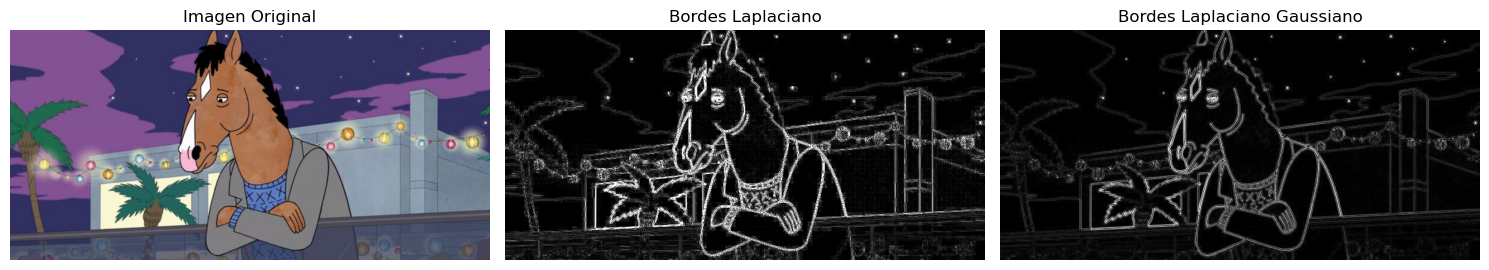

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def laplaciano(img, tamanio_kernel=3):
  # Convertir la imagen a escala de grises
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  # Aplicar el operador Laplaciano para detectar bordes
  # Nuestro input es CV_8U definimos una profundidad CV_16S para evitar desvordamientos
  laplaciano = cv2.Laplacian(img_gray, cv2.CV_16S, ksize=tamanio_kernel)
  # Convertimos de vuelta a uint8
  laplaciano = cv2.convertScaleAbs(laplaciano)
  return laplaciano

def laplacianoGaussiano(img, tamanio_kernel=3):
  # Aplicar suavizado Gaussiano para reducir ruido
  gaussiano = cv2.GaussianBlur(img, (tamanio_kernel, tamanio_kernel), 0)
  # Convertir la imagen a escala de grises
  img_gray = cv2.cvtColor(gaussiano, cv2.COLOR_BGR2GRAY)
  # Aplicar operador Laplaciano para detectar bordes
  # Nuestro input es CV_8U definimos una profundidad CV_16S para evitar desvordamientos
  resultado = cv2.Laplacian(img_gray, cv2.CV_16S, ksize=tamanio_kernel)
  # Convertimos de vuelta a uint8
  resultado = cv2.convertScaleAbs(resultado)
  return resultado

# Cargar imagen
img = cv2.imread('./images/img1.jpeg')

# Aplicar detectores de bordes
img_laplaciano = laplaciano(img)
img_laplaciano_gaussiano = laplacianoGaussiano(img)

# Visualizar resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_laplaciano, cmap='gray')
plt.title('Bordes Laplaciano')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_laplaciano_gaussiano, cmap='gray')
plt.title('Bordes Laplaciano Gaussiano')
plt.axis('off')

plt.tight_layout()
plt.show()